In [116]:
import numpy as np
import matplotlib.pyplot as plt

### naive bayes

In [117]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dataset = load_iris()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [123]:
import pandas as pd

df = pd.DataFrame(dataset.data)
df['target'] = dataset.target
df.groupby('target').mean()

,0,1,2,3
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


#### implementing gaussian nb

In [64]:
from sklearn.base import BaseEstimator
from scipy import stats

In [108]:
class MyNaiveBayes(BaseEstimator):
    def __init__(self, param1=1, param2=2):
        self.param1 = param1
        self.param2 = param2
    def fit(self, X, y):
        # [0, 1, 2, 3, ...]
        labels = np.unique(y)
        class_counts = np.unique_counts(y).counts
        X_grouped = [X[y == label] for label in labels]
        mu = np.array([np.mean(group, axis=0) for group in X_grouped])
        std = np.array([np.std(group, axis=0) for group in X_grouped])

        self.classes_ = labels
        self.class_prob_ = class_counts / y.size
        self.mu_ = mu
        self.std_ = std

        self.is_fitted_ = True
        return self
    def predict(self, X):
        # X -> (n_samples, n_features)
        # X_tile -> (n_classes, n_samples, n_features)
        X_tile = np.tile(X, (self.classes_.size, 1, 1))
        X_class_probs = 1/np.sqrt(2*np.pi*self.std_[:, np.newaxis, :]**2)*np.exp(-(X_tile-self.mu_[:, np.newaxis, :])**2/(2*self.std_[:, np.newaxis, :]**2))
        y_pred_idx = np.argmax(np.sum(np.log2(X_class_probs), axis=2) + np.log2(self.class_prob_[:, np.newaxis]), axis=0)
        y_pred = self.classes_[y_pred_idx]
        return y_pred
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.sum(y_pred == y)/y.size

In [131]:
nb = MyNaiveBayes()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
nb.score(X_test, y_test)

np.float64(0.9111111111111111)

### sklearn gaussian nb

In [130]:
from sklearn.naive_bayes import GaussianNB

nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train, y_train)
nb_sklearn.score(X_test, y_test)

0.9111111111111111

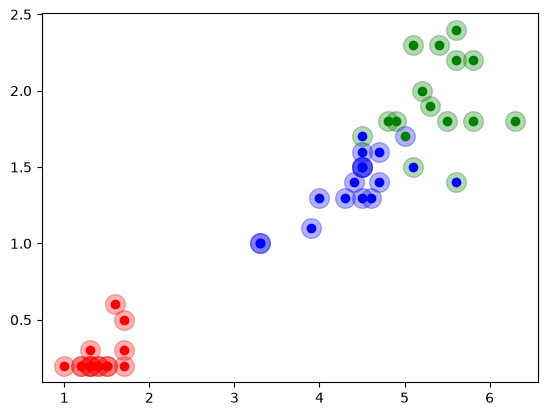

In [133]:
plt.scatter(X_test[y_test==0, 2], X_test[y_test==0, 3], c='red', s=200, alpha=0.3)
plt.scatter(X_test[y_test==1, 2], X_test[y_test==1, 3], c='blue', s=200, alpha=0.3)
plt.scatter(X_test[y_test==2, 2], X_test[y_test==2, 3], c='green', s=200, alpha=0.3)

plt.scatter(X_test[y_pred==0, 2], X_test[y_pred==0, 3], c='red')
plt.scatter(X_test[y_pred==1, 2], X_test[y_pred==1, 3], c='blue')
plt.scatter(X_test[y_pred==2, 2], X_test[y_pred==2, 3], c='green')